## Linear Regression 2
上一节，我们初步了解了 linear regression。现在我们处理一个更复杂的问题，以及我们讨论如何处理“时间”。
如果有相关概念不熟悉的熟悉的话，建议直接问gpt。

在 linear regression（线性回归） 里，“higher-order relationships（高阶关系）” 通常指的是：
自变量与因变量之间不是简单的线性关系，而是通过幂次项、交互项等方式体现的更复杂关系。
下面我们举几个例子：

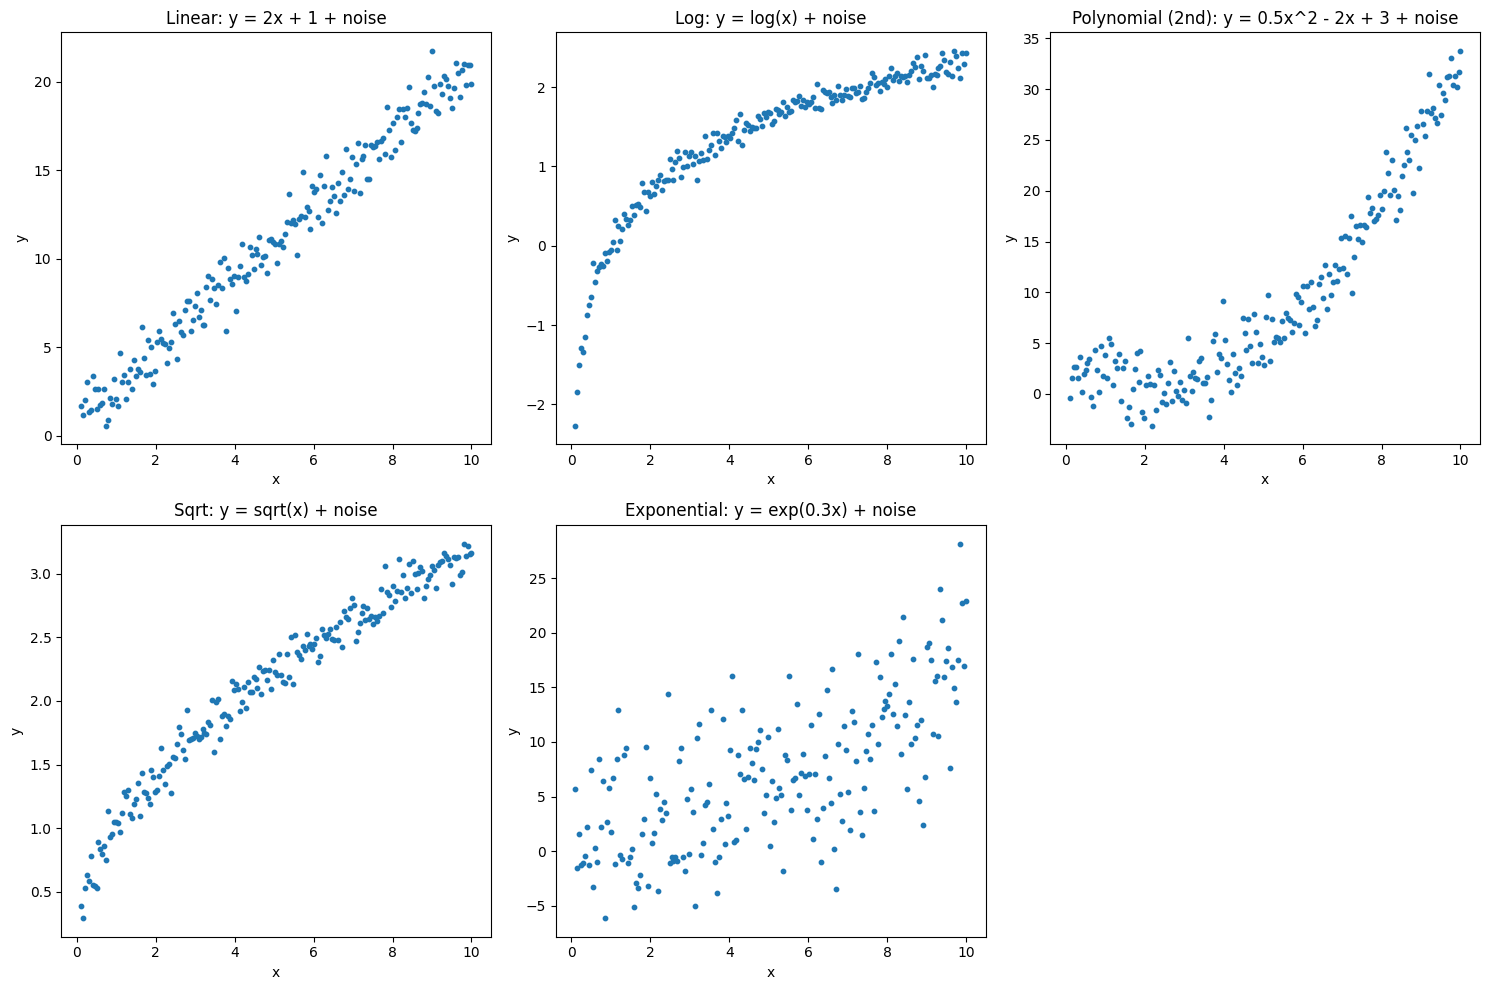

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.linspace(0.1, 10, 200)

# 1) 线性
y_linear = 2 * x + 1 + np.random.normal(0, 1, size=x.shape)

# 2) 对数
y_log = np.log(x) + np.random.normal(0, 0.1, size=x.shape)

# 3) 二次多项式
y_poly2 = 0.5 * x**2 - 2 * x + 3 + np.random.normal(0, 2, size=x.shape)

# 4) 平方根
y_sqrt = np.sqrt(x) + np.random.normal(0, 0.1, size=x.shape)

# 5) 指数
y_exp = np.exp(0.3 * x) + np.random.normal(0, 5, size=x.shape)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.scatter(x, y_linear, s=10)
plt.title("Linear: y = 2x + 1 + noise")
plt.xlabel("x"); plt.ylabel("y")

plt.subplot(2, 3, 2)
plt.scatter(x, y_log, s=10)
plt.title("Log: y = log(x) + noise")
plt.xlabel("x"); plt.ylabel("y")

plt.subplot(2, 3, 3)
plt.scatter(x, y_poly2, s=10)
plt.title("Polynomial (2nd): y = 0.5x^2 - 2x + 3 + noise")
plt.xlabel("x"); plt.ylabel("y")

plt.subplot(2, 3, 4)
plt.scatter(x, y_sqrt, s=10)
plt.title("Sqrt: y = sqrt(x) + noise")
plt.xlabel("x"); plt.ylabel("y")

plt.subplot(2, 3, 5)
plt.scatter(x, y_exp, s=10)
plt.title("Exponential: y = exp(0.3x) + noise")
plt.xlabel("x"); plt.ylabel("y")

plt.tight_layout()
plt.show()


- 现在我们也来考虑 **交互项（interaction terms）**。

- 如果某些特征**只有在彼此同步、共同作用时才显著**，会发生什么？

- 例如：
  - 单独投入报纸广告的效果可能并不明显，但**如果与电视广告活动结合**，其效果可能会大幅提升。

- 只观看电视广告的消费者会带来一定的销量；  
  但**既看了电视广告，又随后通过报纸广告被“提醒”**的消费者，  
  可能带来的销量**甚至超过单独电视广告或报纸广告的效果**。

- 我们该如何验证这一点？

- 最简单的方法是：  
  创建一个**新的特征**，将两个已有特征相乘，从而生成一个**交互项**。

- 我们可以保留原始特征，并在此基础上**额外加入这个交互项**。

- 幸运的是，**Scikit-Learn** 可以通过一次简单的预处理调用，轻松帮我们完成这一步。

- Scikit-Learn 的 `preprocessing`（预处理）库中包含了许多有用的工具，  
  可在模型训练之前对原始数据集进行处理。

- 其中一个工具是 **`PolynomialFeatures`**，  
  它可以**自动生成高阶多项式特征**，以及**所有特征组合之间的交互项**。

- 将两个特征 A 和 B 转换后，得到的特征为：1, A, B, A², AB, B²
- 对特征 X1 和 X2 的一般形式为：1, X1, X2, X1², X1X2, X2²

degree 是什么？（一句话定义）

在 PolynomialFeatures 里：

degree（阶数）指的是：
生成的特征中，单个特征里“所有变量的指数之和”的最大值。

### 看看数据

<Axes: >

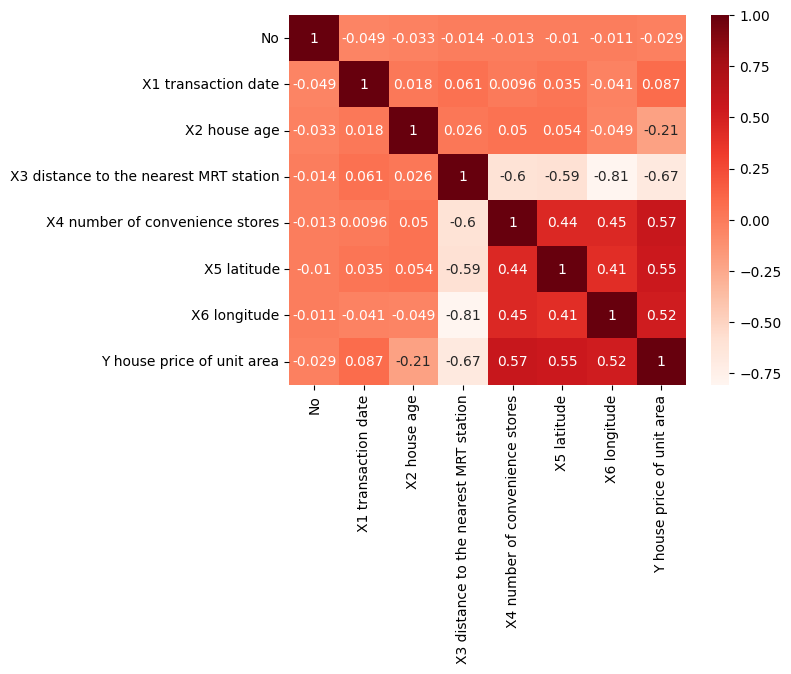

In [4]:
import pandas as pd
import seaborn as sns
df= pd.read_csv('./dataset/Real estate.csv')
sns.heatmap(df.corr(), annot=True,cmap="Reds")


### preprocessing
废话不多说，直接开始预处理

In [ ]:

from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn import metrics

from joblib import dump, load

X=df.drop('Y house price of unit area', axis=1)

y=df['Y house price of unit area']

# Transform the features into polynomial features
polynomial_converter=PolynomialFeatures(degree=2, include_bias=False)

# Fit and transform the features, 这里是两步哦，注意！
poly_features=polynomial_converter.fit(X)
X_poly=poly_features.transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=666)

In [12]:
poly_features.n_output_features_

35

In [13]:
X_poly.shape

(414, 35)

### Train a model

In [14]:
polymodel=LinearRegression()
polymodel.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Predictions and Evaluation

In [ ]:
y_pred=polymodel.predict(X_test)

,Y_Test,Y_Pred,Residuals
235,39.3,41.371801,-2.071801
181,55.9,49.218597,6.681403
220,78.3,45.456367,32.843633
232,17.4,15.536462,1.863538
64,25.3,33.497962,-8.197962


In [ ]:
MAE_Poly = metrics.mean_absolute_error(y_test,y_pred)
MSE_Poly = metrics.mean_squared_error(y_test,y_pred)
RMSE_Poly = np.sqrt(MSE_Poly)

pd.DataFrame([MAE_Poly, MSE_Poly, RMSE_Poly], index=['MAE', 'MSE', 'RMSE'], columns=['metrics'])
## 这里和上一个notebook比较，已经好了一点

,metrics
MAE,5.366684
MSE,56.309539
RMSE,7.503968


### 调整模型参数
那怎么让模型更好呢？非常暴力简单的 **Grid Search**, 没错，就是把不同的degree都试一遍。

In [ ]:
# Train List of RMSE per degree
train_RMSE_list=[]
#Test List of RMSE per degree
test_RMSE_list=[]

for d in range(1,10):
    
    #Preprocessing
    #create poly data set for degree (d)
    polynomial_converter= PolynomialFeatures(degree=d, include_bias=False)
    poly_features= polynomial_converter.fit(X)
    poly_features= polynomial_converter.transform(X)
    
    #Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    #Train the Model
    polymodel=LinearRegression()
    polymodel.fit(X_train, y_train)
    
    #Predicting on both Train & Test Data
    y_train_pred=polymodel.predict(X_train)
    y_test_pred=polymodel.predict(X_test)
    
    #Evaluating the Model
    
    #RMSE of Train set
    train_RMSE=np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))
    
    #RMSE of Test Set
    test_RMSE=np.sqrt(metrics.mean_squared_error(y_test, y_test_pred))
    
    #Append the RMSE to the Train and Test List
    
    train_RMSE_list.append(train_RMSE)
    test_RMSE_list.append(test_RMSE)

### 结束
好，现在明白了Linear Regression。线性回归算是一个非常基础，但又很好用的方法，广泛用在数分里，或者是用在深度学习的预处理部分，可以反应一些变量之间的关系。